# Microsoft stock analysis with ANN-RNN-LSTM

In [ ]:
#Importing the libraries
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
import pandas as pd
from statsmodels.tsa.seasonal import seasonal_decompose
from sklearn.preprocessing import MinMaxScaler
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import SimpleRNN, LSTM, Dense
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score


##  Data Preprocessing

### Importing the training set

In [2]:
df = pd.read_csv('Microsoft_Stock.csv')
df.head()

,Date,Open,High,Low,Close,Volume
0,4/1/2015 16:00:00,40.60,40.76,40.31,40.72,36865322
1,4/2/2015 16:00:00,40.66,40.74,40.12,40.29,37487476
2,4/6/2015 16:00:00,40.34,41.78,40.18,41.55,39223692
3,4/7/2015 16:00:00,41.61,41.91,41.31,41.53,28809375
4,4/8/2015 16:00:00,41.48,41.69,41.04,41.42,24753438


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1511 entries, 0 to 1510
Data columns (total 6 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Date    1511 non-null   object 
 1   Open    1511 non-null   float64
 2   High    1511 non-null   float64
 3   Low     1511 non-null   float64
 4   Close   1511 non-null   float64
 5   Volume  1511 non-null   int64  
dtypes: float64(4), int64(1), object(1)
memory usage: 71.0+ KB


In [4]:
closed_df=df['Close']

###  Gestion des Valeurs Manquantes

In [7]:
# Identification des valeurs manquantes
missing_values = closed_df.isnull().sum()
missing_values

0

###  Détection des Anomalies

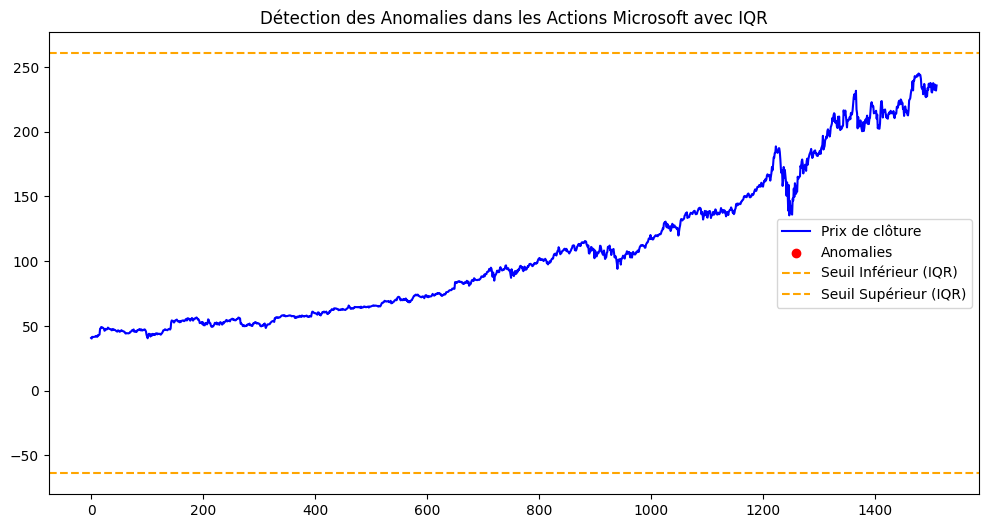

In [14]:

#  Calcul des quartiles et de l'IQR
Q1 = df['Close'].quantile(0.25)
Q3 = df['Close'].quantile(0.75)
IQR = Q3 - Q1

# Définition des seuils d'anomalies
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

# Identification des anomalies
df['anomaly'] = (df['Close'] < lower_bound) | (df['Close'] > upper_bound)

# 📈 Visualisation des anomalies
plt.figure(figsize=(12, 6))
plt.plot(df.index, df['Close'], label="Prix de clôture", color='blue')
plt.scatter(df.index[df['anomaly']], df['Close'][df['anomaly']], 
            color='red', label="Anomalies", marker='o')
plt.axhline(lower_bound, color='orange', linestyle='--', label="Seuil Inférieur (IQR)")
plt.axhline(upper_bound, color='orange', linestyle='--', label="Seuil Supérieur (IQR)")
plt.legend()
plt.title("Détection des Anomalies dans les Actions Microsoft avec IQR")
plt.show()

###  Visualisation des Séries Temporelles

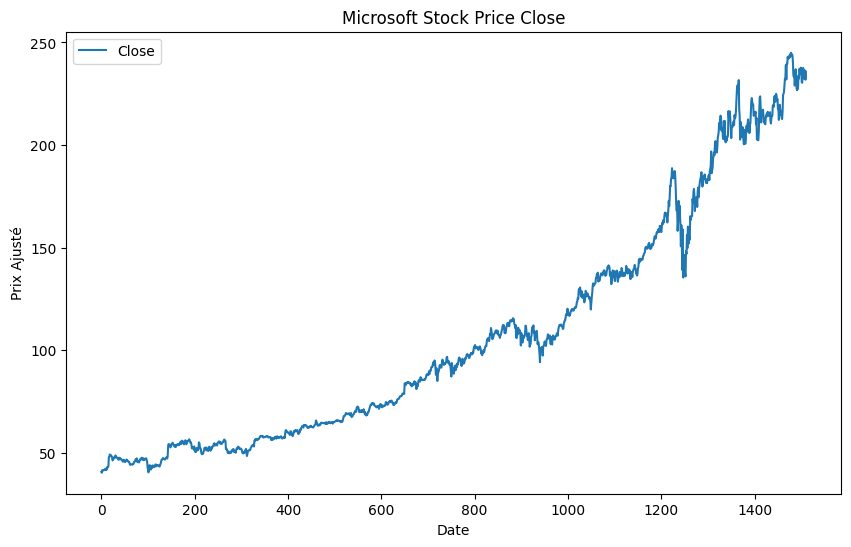

In [16]:
plt.figure(figsize=(10, 6))
plt.plot(closed_df,label='Close')
plt.xlabel('Date')
plt.ylabel('Prix Ajusté')
plt.title('Microsoft Stock Price Close')
plt.legend()
plt.show()

###  Identification des Tendances et Saisonnalités

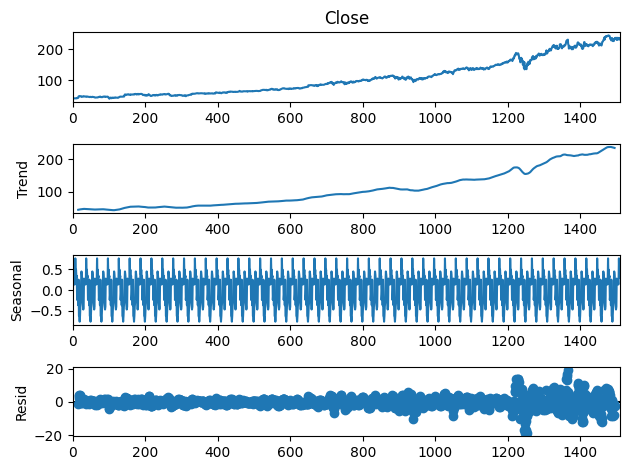

In [17]:

decomposition = seasonal_decompose(df['Close'], model='additive', period=30)  # Ajustez la période si nécessaire
decomposition.plot()
plt.show()


#### Feature Scaling

In [5]:
scaler = MinMaxScaler(feature_range = (0, 1))
scaled_data = scaler.fit_transform(df_no_outliers.values.reshape(-1, 1))
scaled_data

array([[0.00127021],
       [0.00156334],
       [0.        ],
       ...,
       [0.95876692],
       [0.94381748],
       [0.94078851]])

In [7]:
# Préparation des entrées et des cibles
X = []
y = []
for i in range(60, len(scaled_data)):
    X.append(scaled_data[i-60:i, 0])
    y.append(scaled_data[i, 0])

X = np.array(X)
y = np.array(y)


In [8]:
# Diviser en ensembles d'entraînement et de test
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, shuffle=False)

# Reshaping pour les réseaux de neurones
X_train = X_train.reshape(X_train.shape[0], X_train.shape[1])
X_test = X_test.reshape(X_test.shape[0], X_test.shape[1])


### Définition des hyperparamètres

In [9]:

n_epochs = 50
batch_size = 32
optimizer ='adam'

### ANN

In [10]:
# Modèle ANN
ann_model = Sequential([
    Dense(50, input_dim=X_train.shape[1], activation='tanh'),
    Dense(20, activation='relu'),
    Dense(1)
])
ann_model.compile(optimizer=optimizer, loss='mean_squared_error')


In [11]:
# Entraînement du modèle ANN
history_ann = ann_model.fit(X_train, y_train, epochs=n_epochs, batch_size=batch_size, validation_data=(X_test, y_test), verbose=1)

Epoch 1/200
37/37 [==============================] - 10s 97ms/step - loss: 0.0027 - val_loss: 0.0341
Epoch 2/200
37/37 [==============================] - 0s 10ms/step - loss: 6.7107e-04 - val_loss: 0.0130
Epoch 3/200
37/37 [==============================] - 0s 9ms/step - loss: 5.6578e-04 - val_loss: 0.0114
Epoch 4/200
37/37 [==============================] - 0s 11ms/step - loss: 3.2686e-04 - val_loss: 0.0074
Epoch 5/200
37/37 [==============================] - 0s 9ms/step - loss: 2.8216e-04 - val_loss: 0.0079
Epoch 6/200
37/37 [==============================] - 1s 17ms/step - loss: 2.6294e-04 - val_loss: 0.0038
Epoch 7/200
37/37 [==============================] - 0s 6ms/step - loss: 2.2219e-04 - val_loss: 0.0034
Epoch 8/200
37/37 [==============================] - 0s 11ms/step - loss: 2.5078e-04 - val_loss: 0.0030
Epoch 9/200
37/37 [==============================] - 0s 13ms/step - loss: 1.7847e-04 - val_loss: 0.0037
Epoch 10/200
37/37 [==============================] - 0s 13ms/step - l

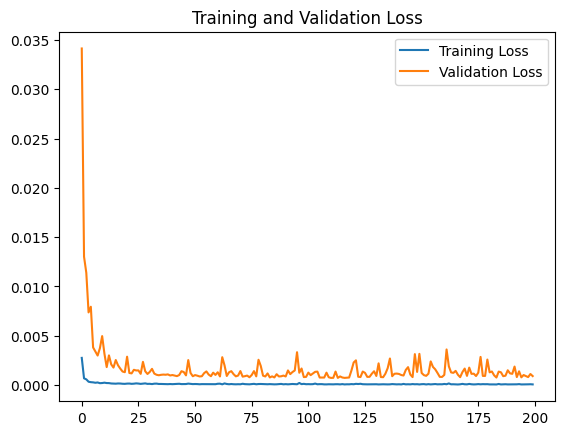

In [12]:
# Affichage des gradients pendant l'entraînement
plt.plot(history_ann.history['loss'], label='Training Loss')
plt.plot(history_ann.history['val_loss'], label='Validation Loss')
plt.title('Training and Validation Loss')
plt.legend()
plt.show()

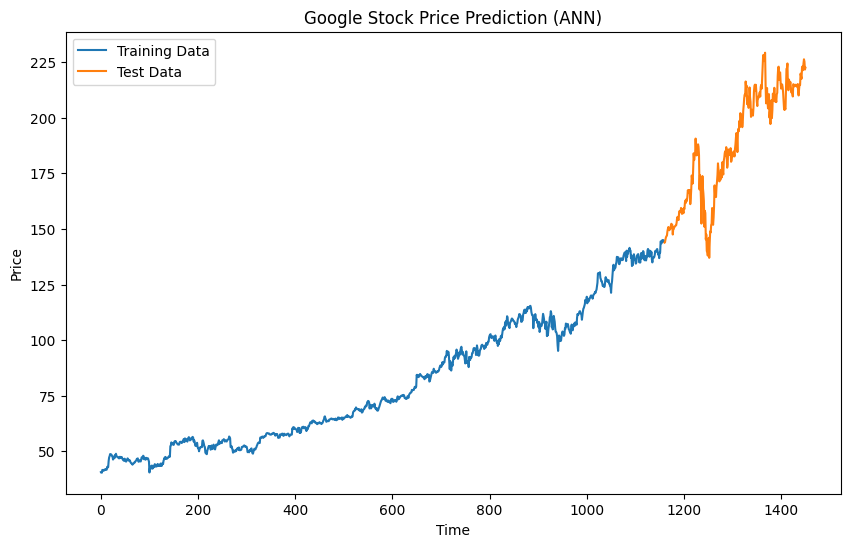

In [14]:
# Create a new array to combine the training data and test data for plotting
train_data = scaler.inverse_transform(scaled_data[:len(X_train)].reshape(-1, 1))
test_data = scaler.inverse_transform(scaled_data[len(X_train):len(X_train)+len(X_test)].reshape(-1, 1))

# Plot training data, test data, and predictions
plt.figure(figsize=(10, 6))
plt.plot(train_data, label='Training Data')
plt.plot(np.arange(len(train_data), len(train_data) + len(test_data)), test_data, label='Test Data')
plt.title('Microsoft Stock Price Prediction (ANN)')
plt.xlabel('Time')
plt.ylabel('Price')
plt.legend()
plt.show()

## RNN

In [15]:
#Modèle RNN
rnn_model = Sequential([
    SimpleRNN(50, activation='tanh', input_shape=(X_train.shape[1], 1)),
    Dense(20, activation='relu'),
    Dense(1)])

rnn_model.compile(optimizer=optimizer, loss='mean_squared_error')
print("Entraînement du modèle RNN...")
history_rnn=rnn_model.fit(X_train, y_train, epochs=n_epochs, batch_size=batch_size, validation_data=(X_test, y_test),verbose=1)

Entraînement du modèle RNN...
Epoch 1/200
37/37 [==============================] - 9s 46ms/step - loss: 0.0074 - val_loss: 0.0207
Epoch 2/200
37/37 [==============================] - 1s 32ms/step - loss: 2.8070e-04 - val_loss: 0.0162
Epoch 3/200
37/37 [==============================] - 1s 21ms/step - loss: 2.0957e-04 - val_loss: 0.0139
Epoch 4/200
37/37 [==============================] - 1s 25ms/step - loss: 1.8810e-04 - val_loss: 0.0129
Epoch 5/200
37/37 [==============================] - 1s 23ms/step - loss: 1.5937e-04 - val_loss: 0.0112
Epoch 6/200
37/37 [==============================] - 1s 21ms/step - loss: 1.6314e-04 - val_loss: 0.0134
Epoch 7/200
37/37 [==============================] - 2s 57ms/step - loss: 1.3110e-04 - val_loss: 0.0116
Epoch 8/200
37/37 [==============================] - 2s 45ms/step - loss: 1.2107e-04 - val_loss: 0.0123
Epoch 9/200
37/37 [==============================] - 1s 31ms/step - loss: 1.1278e-04 - val_loss: 0.0136
Epoch 10/200
37/37 [==================

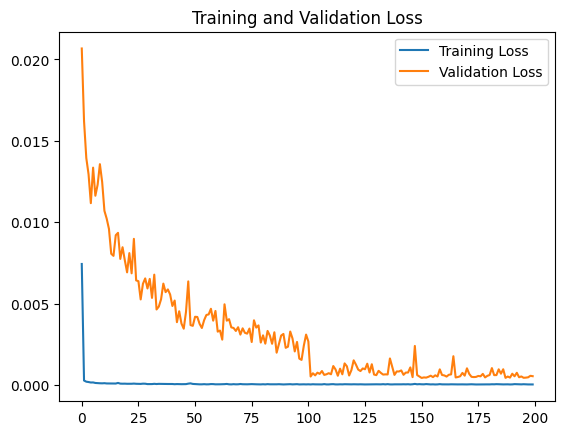

In [16]:
# Affichage des gradients pendant l'entraînement
plt.plot(history_rnn.history['loss'], label='Training Loss')
plt.plot(history_rnn.history['val_loss'], label='Validation Loss')
plt.title('Training and Validation Loss')
plt.legend()
plt.show()

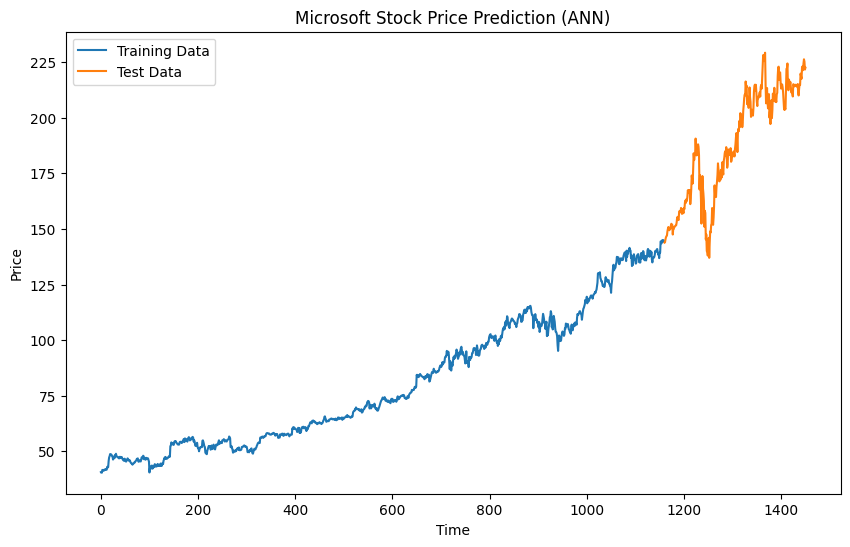

In [17]:
# Plot training data, test data, and predictions
plt.figure(figsize=(10, 6))
plt.plot(train_data, label='Training Data')
plt.plot(np.arange(len(train_data), len(train_data) + len(test_data)), test_data, label='Test Data')
plt.title('Microsoft Stock Price Prediction (ANN)')
plt.xlabel('Time')
plt.ylabel('Price')
plt.legend()
plt.show()

### LSTM

In [18]:
# Modèle LSTM
lstm_model = Sequential([
    LSTM(50, activation='tanh', input_shape=(X_train.shape[1],1 )),
     Dense(20, activation='relu'),
     Dense(1)
])
lstm_model.compile(optimizer=optimizer, loss='mean_squared_error')
print("Entraînement du modèle LSTM...")
history_lstm=lstm_model.fit(X_train, y_train, epochs=n_epochs, batch_size=batch_size, validation_data=(X_test, y_test), verbose=1)

Entraînement du modèle LSTM...
Epoch 1/200
37/37 [==============================] - 15s 100ms/step - loss: 0.0122 - val_loss: 0.0036
Epoch 2/200
37/37 [==============================] - 2s 52ms/step - loss: 1.8280e-04 - val_loss: 0.0014
Epoch 3/200
37/37 [==============================] - 2s 50ms/step - loss: 9.9664e-05 - val_loss: 0.0014
Epoch 4/200
37/37 [==============================] - 2s 57ms/step - loss: 9.6251e-05 - val_loss: 0.0016
Epoch 5/200
37/37 [==============================] - 2s 60ms/step - loss: 9.8597e-05 - val_loss: 0.0013
Epoch 6/200
37/37 [==============================] - 2s 50ms/step - loss: 9.5040e-05 - val_loss: 0.0013
Epoch 7/200
37/37 [==============================] - 2s 55ms/step - loss: 1.0106e-04 - val_loss: 0.0013
Epoch 8/200
37/37 [==============================] - 2s 55ms/step - loss: 9.8850e-05 - val_loss: 0.0013
Epoch 9/200
37/37 [==============================] - 2s 58ms/step - loss: 1.0011e-04 - val_loss: 0.0013
Epoch 10/200
37/37 [===============

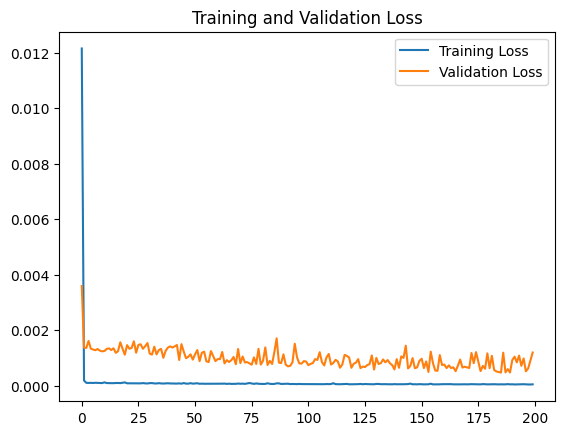

In [19]:
# Affichage des gradients pendant l'entraînement
plt.plot(history_lstm.history['loss'], label='Training Loss')
plt.plot(history_lstm.history['val_loss'], label='Validation Loss')
plt.title('Training and Validation Loss')
plt.legend()
plt.show()

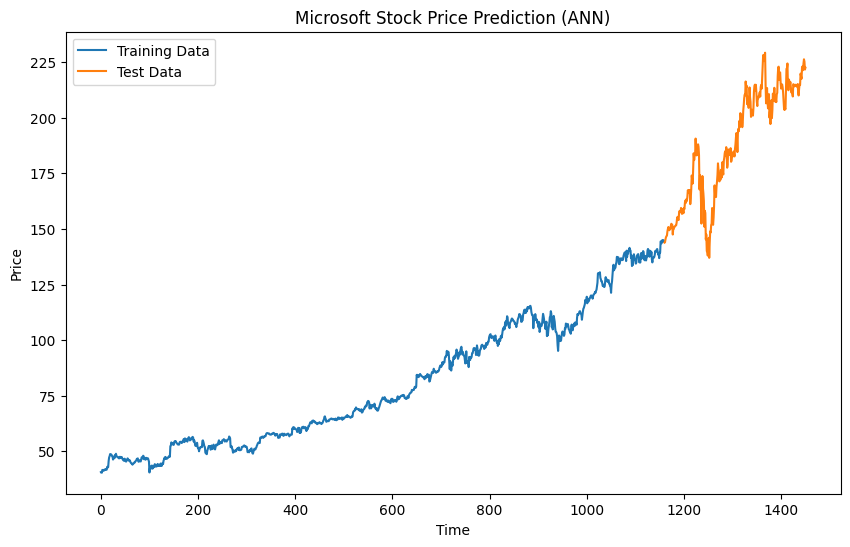

In [20]:
# Plot training data, test data, and predictions
plt.figure(figsize=(10, 6))
plt.plot(train_data, label='Training Data')
plt.plot(np.arange(len(train_data), len(train_data) + len(test_data)), test_data, label='Test Data')
plt.title('Microsoft Stock Price Prediction (ANN)')
plt.xlabel('Time')
plt.ylabel('Price')
plt.legend()
plt.show()

## Evaluation de ANN ,RNN et LSTM

In [21]:
# Évaluation
rnn_loss = rnn_model.evaluate(X_test, y_test, verbose=0)
lstm_loss = lstm_model.evaluate(X_test, y_test, verbose=0)
ann_loss = ann_model.evaluate(X_test, y_test, verbose=0)
print(f"Perte ANN : {ann_loss:.4f}")
print(f"Perte RNN : {rnn_loss:.4f}")
print(f"Perte LSTM : {lstm_loss:.4f}")

Perte ANN : 0.0009
Perte RNN : 0.0005
Perte LSTM : 0.0012


In [22]:
ann_predictions = ann_model.predict(X_test).flatten()
rnn_predictions = rnn_model.predict(X_test).flatten()
lstm_predictions = lstm_model.predict(X_test).flatten()

10/10 [==============================] - 1s 16ms/step


In [23]:
# Inverse Scaling
ann_predictions = scaler.inverse_transform(ann_predictions.reshape(-1, 1))
rnn_predictions = scaler.inverse_transform(rnn_predictions.reshape(-1, 1))
lstm_predictions = scaler.inverse_transform(lstm_predictions.reshape(-1, 1))

y_test_scaled = scaler.inverse_transform(y_test.reshape(-1, 1))


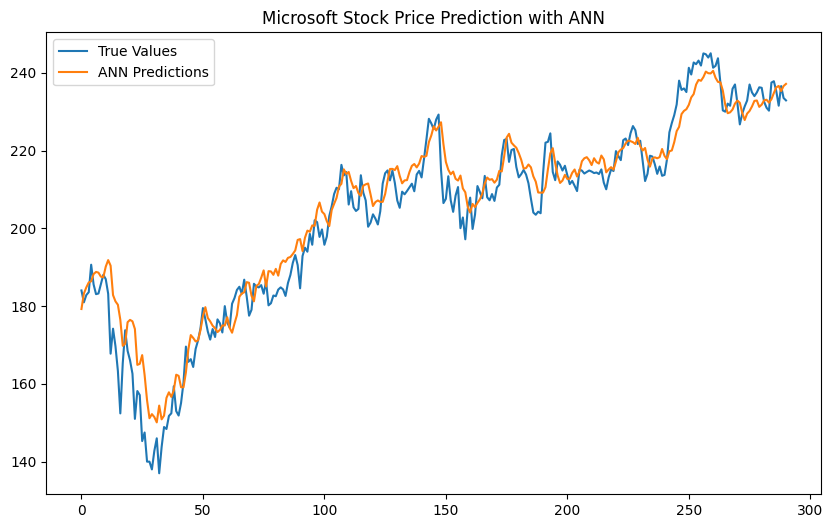

In [24]:
plt.figure(figsize=(10, 6))
plt.plot(y_test_scaled, label='True Values')
plt.plot(ann_predictions, label='ANN Predictions')
plt.title('Microsoft Stock Price Prediction with ANN')
plt.legend()
plt.show()

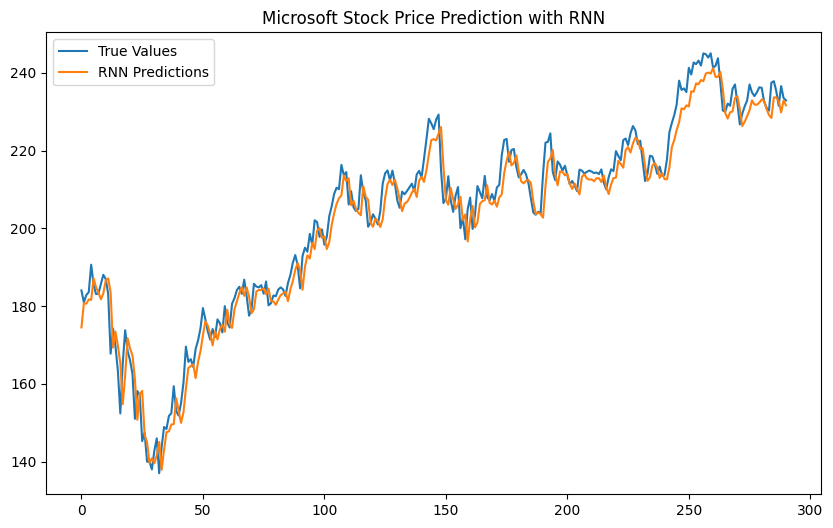

In [25]:
plt.figure(figsize=(10, 6))
plt.plot(y_test_scaled, label='True Values')
plt.plot(rnn_predictions, label='RNN Predictions')
plt.title('Microsoft Stock Price Prediction with RNN')
plt.legend()
plt.show()

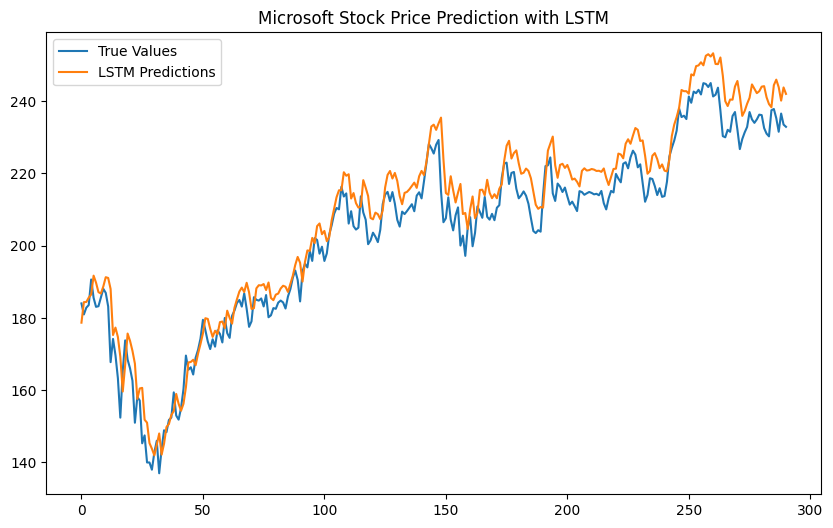

In [26]:
plt.figure(figsize=(10, 6))
plt.plot(y_test_scaled, label='True Values')
plt.plot(lstm_predictions, label='LSTM Predictions')
plt.title('Microsoft Stock Price Prediction with LSTM')
plt.legend()
plt.show()

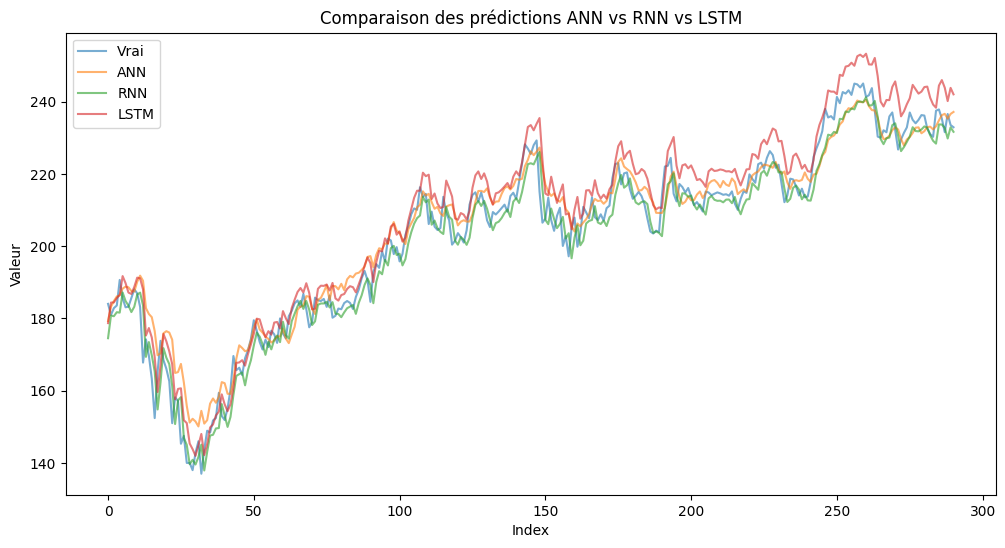

In [27]:
# Tracer les prédictions
plt.figure(figsize=(12, 6))
plt.plot(y_test_scaled, label='Vrai', alpha=0.6)
plt.plot(ann_predictions, label='ANN', alpha=0.6)
plt.plot(rnn_predictions, label='RNN', alpha=0.6)
plt.plot(lstm_predictions, label='LSTM', alpha=0.6)
plt.legend()
plt.title("Comparaison des prédictions ANN vs RNN vs LSTM")
plt.xlabel("Index")
plt.ylabel("Valeur")
plt.show()

In [28]:
print("Evaluation du modèle ANN:")
mse = mean_squared_error(y_test_scaled, ann_predictions)
mae = mean_absolute_error(y_test_scaled, ann_predictions)
r2 = r2_score(y_test_scaled, lstm_predictions)

print(f"Mean Squared Error (MSE): {mse}")
print(f"Mean Absolute Error (MAE): {mae}")
print(f"R² Score: {r2}")

Evaluation du modèle ANN:
Mean Squared Error (MSE): 37.69195471069643
Mean Absolute Error (MAE): 4.747981315691452
R² Score: 0.9202404221886128


In [29]:
print("Evaluation du modèle LSTM:")
mse1 = mean_squared_error(y_test_scaled, lstm_predictions)
mae1 = mean_absolute_error(y_test_scaled, lstm_predictions)
r2_1 = r2_score(y_test_scaled, lstm_predictions)

print(f"Mean Squared Error (MSE): {mse1}")
print(f"Mean Absolute Error (MAE): {mae1}")
print(f"R² Score: {r2_1}")

Evaluation du modèle LSTM:
Mean Squared Error (MSE): 49.95174396605034
Mean Absolute Error (MAE): 5.9236245884846195
R² Score: 0.9202404221886128


In [30]:
print("Evaluation du modèle RNN:")
mse2 = mean_squared_error(y_test_scaled, rnn_predictions)
mae2 = mean_absolute_error(y_test_scaled, rnn_predictions)
r2_2 = r2_score(y_test_scaled, rnn_predictions)

print(f"Mean Squared Error (MSE): {mse2}")
print(f"Mean Absolute Error (MAE): {mae2}")
print(f"R² Score: {r2_2}")


Evaluation du modèle RNN:
Mean Squared Error (MSE): 22.904687283597262
Mean Absolute Error (MAE): 3.7893106551022866
R² Score: 0.9634273392159602


In [31]:

explication = {
    "Modèle": ["LSTM", "RNN", "ANN"],
    "Pourquoi il est performant": [
        "Meilleur pour les séries temporelles",
        "Mieux que ANN pour gérer les séquences",
        "Moins performant pour les séries temporelles"
    ],
    "Explication": [
        "LSTM est optimal pour les séries temporelles grâce à sa gestion des dépendances longues.",
        
        "RNN gère les séquences mais ne capture pas aussi bien les dépendances longues que LSTM.",
        
        "ANN ne prend pas en compte les relations temporelles, ce qui le rend moins adapté."
    ]
}

# Créer un DataFrame pandas à partir des données
df_summary = pd.DataFrame(explication)

# Afficher le tableau récapitulatif
df_summary


,Modèle,Pourquoi il est performant,Explication
0,LSTM,Meilleur pour les séries temporelles,LSTM est optimal pour les séries temporelles g...
1,RNN,Mieux que ANN pour gérer les séquences,RNN gère les séquences mais ne capture pas aus...
2,ANN,Moins performant pour les séries temporelles,ANN ne prend pas en compte les relations tempo...
